In [1]:
import pandas as pd
import numpy as np
import nfl_data_py as nfl
from pygam import LinearGAM, s, f, te
import matplotlib.pyplot as plt
import data_processing_functions as helpy
import manual_ml_stuff as ml
import lightgbm as lgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [3]:
recieving_2024 = helpy.get_year_table(2024)
recieving_2023 = helpy.get_year_table(2023)
recieving_2022 = helpy.get_year_table(2022)
recieving_2021 = helpy.get_year_table(2021)
recieving_2020 = helpy.get_year_table(2020)
recieving_2019 = helpy.get_year_table(2019)
recieving_2018 = helpy.get_year_table(2018)

In [4]:
recieving = helpy.merge_datasets([recieving_2018, recieving_2019, recieving_2020, 
                                  recieving_2021, recieving_2022, recieving_2023, recieving_2024])

skills in order: efficency vs man and zone seperately, threat to all parts of the field, drops, positional value, translatability 

In [5]:
X = recieving[['behind_los_yards', 'short_yards', 'medium_yards', 'deep_yards', 'yprr',
               'is_power_four', 'drop_rate', 'wide_rate']]
    
y = recieving['pick']

In [6]:
X = X.fillna(0)

In [7]:
X['is_power_four'] = X['is_power_four'].astype(np.float32)

In [8]:
X_norm = (X - X.min()) / (X.max() - X.min())

In [9]:
# Convert to PyTorch tensors
X_tensor = torch.tensor(X_norm.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)

In [10]:
# Dataset & DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [11]:
model = ml.NonMonotoneMultiplicativeModel()
loss_fn = nn.MSELoss()  # regression
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [12]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    epoch_loss = 0
    for x_batch, y_batch in dataloader:
        optimizer.zero_grad()              # Step 1: reset gradients
        y_pred = model(x_batch)            # Step 2: forward pass
        loss = loss_fn(y_pred, y_batch)   # Step 3: compute loss
        loss.backward()                    # Step 4: backward pass (compute gradients)
        optimizer.step()                   # Step 5: update weights
        epoch_loss += loss.item() * x_batch.size(0)
    
    epoch_loss /= len(dataloader.dataset)
    return epoch_loss

In [13]:
n_epochs = 500
epoch_losses = []

for epoch in range(n_epochs):
    
    epoch_loss = train_one_epoch(dataloader, model, loss_fn, optimizer)
    
    num_worse_than = 0
    
    if epoch > 30:
        for loss in epoch_losses[-20:]:
            if loss < epoch_loss:
                num_worse_than = num_worse_than + 1
                
        if num_worse_than > 15:
            n_epochs = epoch
            break
        
    epoch_losses.append(epoch_loss)
    

KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (156,) and (128,)

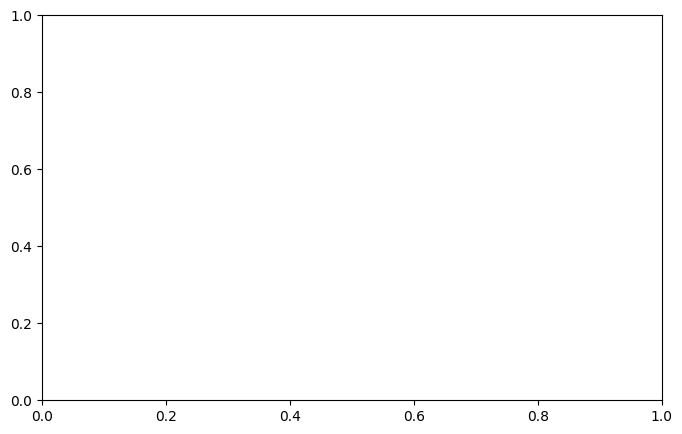

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, n_epochs+1), epoch_losses, label='Train Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.eval()
with torch.no_grad():  # no gradients needed for prediction
    y_pred = model(X_tensor)  # X: tensor of shape (num_samples, 11)

In [ ]:
y_pred

tensor([[ 51.6931],
        [144.0114],
        [ 75.7730],
        [ 96.8733],
        [ 93.3475],
        [ 78.2594],
        [ 72.3136],
        [ 65.6588],
        [146.7409],
        [141.0603],
        [146.3456],
        [ 77.4012],
        [ 30.7844],
        [114.4051],
        [109.6964],
        [149.0961],
        [140.3339],
        [182.5585],
        [105.5783],
        [158.3427],
        [163.0995],
        [112.4525],
        [115.5456],
        [153.6557],
        [111.5630],
        [ 79.9626],
        [ 53.3802],
        [ 83.6568],
        [124.3192],
        [120.8473],
        [128.0580],
        [ 68.6643],
        [ 82.9964],
        [ 92.7194],
        [ 90.1309],
        [ 49.2771],
        [139.1983],
        [ 97.8163],
        [104.3795],
        [219.1691],
        [121.0226],
        [117.6196],
        [ 52.6993],
        [166.1767],
        [ 82.7201],
        [227.0036],
        [132.0021],
        [138.2228],
        [142.2163],
        [162.0378],


In [ ]:
recieving['predicted_slot'] = y_pred

In [ ]:
recieving[['behind_los_yards', 'short_yards', 'medium_yards', 'deep_yards', 'yprr',
               'is_power_four', 'drop_rate', 'wide_rate', 'player', 'college', 'is_power_four', 'predicted_slot']]

,behind_los_yards,short_yards,medium_yards,deep_yards,yprr,is_power_four,drop_rate,wide_rate,player,college,is_power_four,predicted_slot
0,170,351,470,705,4.15,False,5.6,55.8,Andy Isabella,Massachusetts,False,51.693104
1,21,513,386,423,2.33,False,12.7,3.0,John Ursua,Hawaii,False,144.011353
2,90,321,264,509,2.90,True,9.6,76.5,Dillon Mitchell,Oregon,True,75.773010
3,101,389,314,541,3.06,False,6.8,69.6,KeeSean Johnson,Fresno St.,False,96.873337
4,31,302,387,466,2.83,True,4.7,96.4,Kelvin Harmon,North Carolina St.,True,93.347504
5,104,457,359,387,3.01,True,5.6,40.4,A.J. Brown,Mississippi,True,78.259445
6,213,213,386,276,2.71,True,6.4,66.5,N'Keal Harry,Arizona St.,True,72.313599
7,441,408,169,53,3.47,True,5.2,11.5,Parris Campbell,Ohio St.,True,65.658813
8,0,368,390,379,3.06,False,6.7,16.3,Scott Miller,Bowling Green,False,146.740860
9,0,152,359,572,2.20,False,7.4,88.8,Travis Fulgham,Old Dominion,False,141.060318
